# 12 — The event viewer

`examples/eventviewer/` is an interactive picture of one simulated event: the
array seen from above with the antennas that were hit coloured by when they
were hit; click one and its electric field appears beside it; underneath, the
same peak amplitudes redrawn in three other planes where the Cherenkov ring is
easier to see. Press **Play** and the footprint fills in, antenna by antenna,
in the order the signal arrived.

It is a small web application, built on Panel and HoloViews, and its natural
home is a browser tab. This notebook does three things with it:

1. shows how to **run** it, from the command line and from Python;
2. **opens up** what it computes, drawing each panel as a static figure, so
   you know what you are looking at before you look at it — and so this page
   has pictures on GitHub, which cannot display the interactive version;
3. says plainly **what to trust**: one of its panels was wrong until September
   2026, and another is still off on the committed sample data, for a reason
   that lies outside the viewer.

**Prerequisites**: the `grand-dev` environment plus the viewer's plotting
stack, which is not part of the normal environment:

```bash
pip install -e ".[viewer]"      # panel, holoviews, bokeh, pandas, seaborn
```

## 1. Running it the usual way

From the root of the repository, point it at a run directory — the sim2root
layout, one tree per file:

```bash
python examples/eventviewer/event_viewer_to_root.py \
    --datadir sim2root/Common/sim_Xiaodushan_20221026_000000_RUN1_CD_ZHAireS_0000/
```

It prints a URL; open it in a browser. The options:

| Option | Default | What it does |
|---|---|---|
| `--datadir` | (required) | the run to show |
| `--event N` | 0 | which event in the run, by entry number |
| `--gf FILE` | the 2021 proposed GP300 layout | the grey array drawn behind the hits |
| `--port P` | 46813 | move it if that port is taken |
| `--host H` | `localhost` | `0.0.0.0` publishes it to the whole network |

The last one deserves its sentence: on a shared machine such as a cluster
login node, `0.0.0.0` means anyone who can reach the machine can open your
viewer. It used to be the default; it no longer is.

The rest of this notebook drives it from Python instead, which is what you want
to look inside it.

## 2. Loading it from Python

The viewer is a script in `examples/`, not part of the `grand` package, so it
is imported by path. It imports its helper `mix.py` as a bare sibling module,
which is why the directory itself goes on `sys.path`. HoloViews needs a
plotting backend chosen before anything is built.

In [1]:
import contextlib
import io
import logging
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# ROOT reports every branch a file does not carry; those lines would bury the output.
logging.getLogger("grand").setLevel(logging.ERROR)

VIEWER_DIR = os.path.abspath("../examples/eventviewer")
if VIEWER_DIR not in sys.path:
    sys.path.insert(0, VIEWER_DIR)

import holoviews as hv
from IPython.utils.capture import capture_output

# hv.extension also emits the JavaScript a live notebook needs to draw
# HoloViews plots. Nothing here is drawn by HoloViews, so that is captured
# rather than stored in the notebook.
with capture_output():
    hv.extension("bokeh")

import event_viewer_to_root as ev
import mix

SAMPLE = "../sim2root/Common/sim_Xiaodushan_20221026_000000_RUN1_CD_ZHAireS_0000"

`EventViewer` takes the run directory and which event to show. Nothing is read
until `view()` is called: it loads the background layout, reads the event
through `grand.aoi`, filters every trace, and assembles the page.

`view(serve=False)` returns the page **without** starting a web server. That is
what the viewer's test uses, and it is what makes the rest of this notebook
possible. `view()` with no argument builds the same page and serves it.

The viewer narrates as it loads, with bare `print`s:

In [2]:
viewer = ev.EventViewer(SAMPLE, event=0)
page = viewer.view(serve=False)
print("\nbuilt:", type(page).__name__)

Initialization
Reading directory ../sim2root/Common/sim_Xiaodushan_20221026_000000_RUN1_CD_ZHAireS_0000


Number of events: 2
Run information loaded.
Voltage information loaded.


Efield information loaded.
Simulated shower information loaded.
Event 0, du_id 46, time 1976-05-13T17:01:59.999986676
B field: inclination 61.60 deg, declination 0.13 deg, strength 56.48 (unit as stored)



built: GridSpec


Five of those lines come from the viewer, four from `grand.aoi` announcing
each tree it loads (notebook 09 has more on that). The line worth reading is the
**B field** one; section 5 is about it.

Everything the page draws is now an attribute of `viewer`, in plain NumPy:

| Attribute | What |
|---|---|
| `primary`, `energy`, `zenith`, `azimuth` | the simulated shower; energy in EeV, angles in radians, "comes from" |
| `x_xmax`, `y_xmax`, `z_xmax`, `slant_xmax` | Xmax, in metres from the core; its depth in g/cm² |
| `corex`, `corey` | the shower core |
| `hitX`, `hitY`, `hitZ` | antenna positions, metres, x North, y West, z Up |
| `peaktime`, `peakamplitude` | per antenna: when and how high the filtered Hilbert envelope peaked |
| `bx`, `by`, `bz` | the geomagnetic field's direction |
| `efields` | the `grand.aoi` electric-field objects, one per antenna |

In [3]:
print("primary        %s" % viewer.primary)
print("energy         %.2f EeV" % viewer.energy)
print("zenith         %.2f deg   azimuth %.2f deg" % (np.degrees(viewer.zenith), np.degrees(viewer.azimuth)))
print("Xmax depth     %.1f g/cm2" % viewer.slant_xmax)
print("antennas hit   %d" % viewer.nhits)
print("peaks span     %.1f microseconds" % (np.ptp(viewer.peaktime) * 1e6))
print("brightest      %.0f uV/m" % viewer.peakamplitude.max())

primary        2212
energy         3.87 EeV
zenith         79.43 deg   azimuth 310.00 deg
Xmax depth     794.6 g/cm2
antennas hit   44
peaks span     40.4 microseconds
brightest      1822 uV/m


**How it picks the peak.** For each antenna it band-passes the three field
components to 50–200 MHz (`viewer.fmin`, `viewer.fmax` — GRAND's band), takes
the Hilbert envelope of each, and records the largest envelope value and the
moment it occurs. Changing the band means setting those two attributes
*before* `view()`.

## 3. The main panel: the footprint

The large panel on the left is the array from above. Grey circles are the
**background layout**; coloured ones are the antennas **in the data**,
coloured by peak time, early to late.

Two things to know when you read it:

- **The axes are not map axes.** Horizontal is South→North, vertical is
  East→West: GRAND's x and y as they come. North is to the *right*.
- **The grey array is not read from your data.** It is
  `GP300propsedLayout.dat`, the layout proposed for GP300 in 2021: 288
  antennas, denser in the middle. The hits come from the data; the background
  does not. For this sample the two agree, every hit within a metre of a
  background antenna, because the sample was simulated on that same layout.
  For any other array they will not line up, and the viewer will not warn
  you.

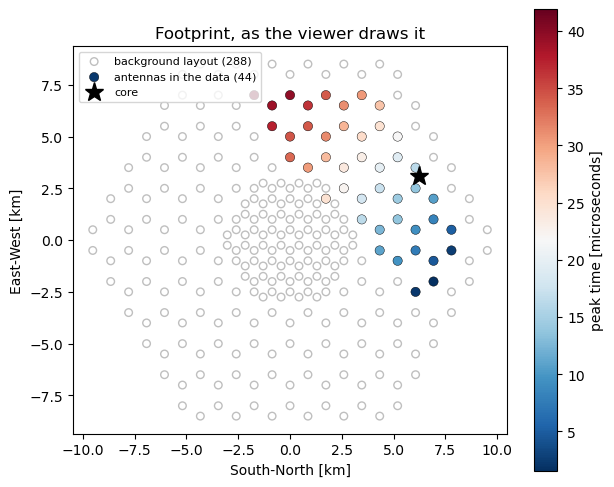

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(viewer.posx, viewer.posy, s=30, facecolors="none", edgecolors="0.75",
           label="background layout (%d)" % len(viewer.posx))
sc = ax.scatter(viewer.hitX / 1e3, viewer.hitY / 1e3, c=viewer.peaktime * 1e6,
                cmap="RdBu_r", s=45, edgecolors="k", linewidths=0.3,
                label="antennas in the data (%d)" % viewer.nhits)
ax.plot(viewer.corex / 1e3, viewer.corey / 1e3, "k*", ms=14, label="core")
fig.colorbar(sc, ax=ax, label="peak time [microseconds]")
ax.set_xlabel("South-North [km]")
ax.set_ylabel("East-West [km]")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Footprint, as the viewer draws it")
plt.show()

The colour sweeps across the footprint in the direction the shower travels:
the first antennas hit are on the side it came from. **Play** in the browser
does exactly that sweep, revealing antennas in 60 equal steps of peak time.

## 4. Click an antenna: its trace

Clicking a coloured antenna shows its electric field — the three components
after the band-pass — and below it their Hilbert envelopes. Here is the one the
viewer selects when the page opens, the middle entry:

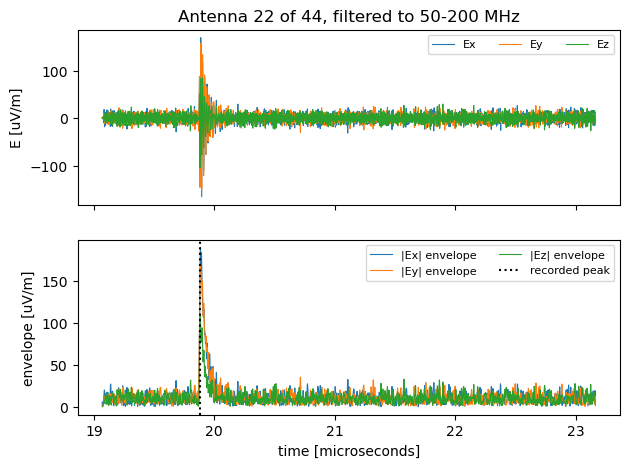

peak 189 uV/m at 19.885 microseconds


In [5]:
from scipy.signal import hilbert

i = viewer.nhits // 2
efield = viewer.efields[i]
t_s = efield.t_vector * 1e-9                  # the trace's clock, nanoseconds to seconds
filtered = mix.filters_root(t_s, efield.trace, FREQMIN=viewer.fmin, FREQMAX=viewer.fmax)
t_us = filtered[0] * 1e6
envelope = np.abs(hilbert(filtered[1:4]))

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
for axis, label in enumerate("xyz"):
    top.plot(t_us, filtered[1 + axis], lw=0.8, label="E" + label)
    bottom.plot(t_us, envelope[axis], lw=0.8, label="|E%s| envelope" % label)
bottom.axvline(viewer.peaktime[i] * 1e6, color="k", ls=":", label="recorded peak")
top.set_ylabel("E [uV/m]")
bottom.set_ylabel("envelope [uV/m]")
bottom.set_xlabel("time [microseconds]")
top.set_title("Antenna %d of %d, filtered to %.0f-%.0f MHz"
              % (i, viewer.nhits, viewer.fmin / 1e6, viewer.fmax / 1e6))
top.legend(fontsize=8, ncol=3)
bottom.legend(fontsize=8, ncol=2)
plt.show()
print("peak %.0f uV/m at %.3f microseconds" % (viewer.peakamplitude[i], viewer.peaktime[i] * 1e6))

The dotted line is the moment stored in `peaktime`; the height of the tallest
envelope there is `peakamplitude`. Those two numbers per antenna are all the
remaining panels use.

## 5. The shower plane, and the magnetic field

The radio emission is organised by two directions: the shower axis
$\mathbf{v}$, and the geomagnetic field $\mathbf{B}$. The dominant emission is
polarised along $\mathbf{v}\times\mathbf{B}$, so the natural frame to look at a
footprint in is

- $\mathbf{v}\times\mathbf{B}$ — horizontal axis
- $\mathbf{v}\times(\mathbf{v}\times\mathbf{B})$ — vertical axis

projecting each antenna onto the plane perpendicular to the axis. The
elongated ellipse on the ground becomes, roughly, a circle — the Cherenkov
ring — and its asymmetries line up with the axes. That is the **Shower Plane**
panel.

**Until September 2026 its axes pointed the wrong way.** The simulated shower
stores `magnetic_field` as three numbers — inclination, declination, strength
— and the viewer used to treat those three numbers as the components of a
vector. At the Xiaodushan site that "vector" is 104° from the real field:

In [6]:
import glob
from grand.dataio import TShower                # read the three stored numbers directly

tree = TShower(glob.glob(os.path.join(SAMPLE, "shower_*_L0_*.root"))[0])
tree.get_entry(0)
stored = np.array(tree.magnetic_field, dtype=float)
print("stored magnetic_field = [%.2f, %.2f, %.2f]  (inclination deg, declination deg, strength)"
      % tuple(stored))

old = stored / np.linalg.norm(stored)                     # what the viewer used to do
new = np.array([viewer.bx, viewer.by, viewer.bz])         # what it does now
print("old direction  ", np.round(old, 3))
print("new direction  ", np.round(new, 3), "  (x North, y West, z Up)")
print("angle between them: %.0f deg" % np.degrees(np.arccos(np.clip(old @ new, -1, 1))))

stored magnetic_field = [61.60, 0.13, 56.48]  (inclination deg, declination deg, strength)
old direction   [0.737 0.002 0.676]
new direction   [ 0.476 -0.001 -0.88 ]   (x North, y West, z Up)
angle between them: 104 deg


The fix builds the direction from the angles: the field dips below the
horizon by the inclination, and its horizontal part points the declination
east of North. The viewer's test checks it against GRANDlib's geomagnetic
model at the site and fails on the old code.

The field's *strength* is not used, which is fortunate: the ZHAireS converter
stores it in µT and the CoREAS one in gauss, with no unit recorded
([known issue](https://grand-mother.github.io/grand-docs/known_issues.html#issue-magnetic-field-units)).

Here is the shower plane as the viewer now computes it — each antenna placed
by its position around the axis and coloured by its peak amplitude. The
viewer's panel interpolates between antennas to fill the square; the points
are what that interpolation is made from.

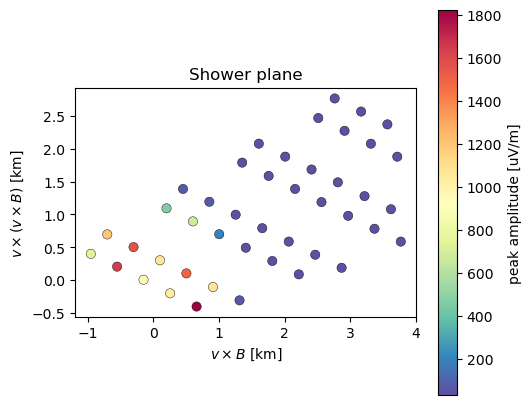

In [7]:
with contextlib.redirect_stdout(io.StringIO()):
    viewer.peak_amplitude_shower_plane(None)        # fills viewer.x_sp, viewer.y_sp

fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(viewer.x_sp / 1e3, viewer.y_sp / 1e3, c=viewer.peakamplitude,
                cmap="Spectral_r", s=45, edgecolors="k", linewidths=0.3)
fig.colorbar(sc, ax=ax, label="peak amplitude [uV/m]")
ax.set_xlabel(r"$v\times B$ [km]")
ax.set_ylabel(r"$v\times(v\times B)$ [km]")
ax.set_aspect("equal")
ax.set_title("Shower plane")
plt.show()

The origin is the shower axis. The bright antennas all lie within about a
kilometre of it, on one side; everything farther out is dim. For a shower
this inclined the array catches only part of the footprint, so what shows is
an arc of the bright region rather than a whole ring.

The axes are what the fix changed. With the old field, the same points were
turned by about 100° about the origin, so any pattern that lines up with
$\mathbf{v}\times\mathbf{B}$ — the polarisation, and the asymmetry of the
footprint — lined up with the wrong axis.

## 6. The angular plane, and a caveat that is not the viewer's

The **Angular Plane** redraws the same antennas by *angle* rather than
distance: how far off the axis each one is, as seen **from Xmax**. The radius
is the angle $\omega$; the direction around the centre is the same as in the
shower plane. In this plane the Cherenkov ring has a physical radius — the
Cherenkov angle, around a degree — and the fourth panel, **Cherenkov Angle**,
plots amplitude against $\omega$ directly so you can read it off.

That makes the panel only as good as the Xmax position it measures from, and
**on the sample data committed to this repository, Xmax is 1264 m too high**.
The samples predate a fix in the ZHAireS converter and store Xmax's height
above sea level where the format means height above the ground; the ground at
Xiaodushan is at 1264 m. It is
[grand-mother/grand#160](https://github.com/grand-mother/grand/issues/160), and
its [known-issues entry](https://grand-mother.github.io/grand-docs/known_issues.html#issue-xmax-sample-vintage)
explains why regenerating the samples does not simply fix it.

The viewer reads the field as stored, so its angular plane inherits the
offset. Measure it on both events in this run, by moving Xmax down by 1264 m
and computing the angles again:

In [8]:
GROUND = 1264.0                                      # metres; origin_geoid[2] of the sample

def angles_from_xmax(v):
    """The viewer's own angular-plane computation; returns omega in degrees."""
    with contextlib.redirect_stdout(io.StringIO()):
        v.peak_amplitude_shower_plane(None)
        v.peak_amplitude_angular_plane(None)
    return np.degrees(v.w).copy()

viewers = {}
for n in (0, 1):
    with contextlib.redirect_stdout(io.StringIO()):
        v = ev.EventViewer(SAMPLE, event=n)
        v.view(serve=False)
    as_stored = angles_from_xmax(v)
    v.z_xmax -= GROUND
    corrected = angles_from_xmax(v)
    v.z_xmax += GROUND                                  # leave the viewer as it was
    viewers[n] = (v, as_stored, corrected)
    print("event %d: zenith %.1f deg, Xmax %.1f km above the core as stored"
          % (n, np.degrees(v.zenith), v.z_xmax / 1e3))
    print("         omega moves by up to %.2f deg; antennas span %.2f-%.2f deg, then %.2f-%.2f deg"
          % (np.abs(corrected - as_stored).max(), as_stored.min(), as_stored.max(),
             corrected.min(), corrected.max()))

event 0: zenith 79.4 deg, Xmax 13.9 km above the core as stored
         omega moves by up to 1.02 deg; antennas span 0.41-3.75 deg, then 0.12-3.36 deg


event 1: zenith 51.6 deg, Xmax 5.8 km above the core as stored
         omega moves by up to 6.49 deg; antennas span 1.98-10.85 deg, then 4.36-7.21 deg


For the steep shower, event 1, the angles move by 6.5°, far more than the
width of a Cherenkov ring. There is little to see in it, though: that event
reached only five antennas, all faint. The inclined shower, event 0, has its
Xmax much farther away, so the same 1264 m moves its angles by about 1° —
comparable with the ring itself, and on 44 antennas.

Side by side, amplitude against angle — the Cherenkov-angle panel — for
event 0:

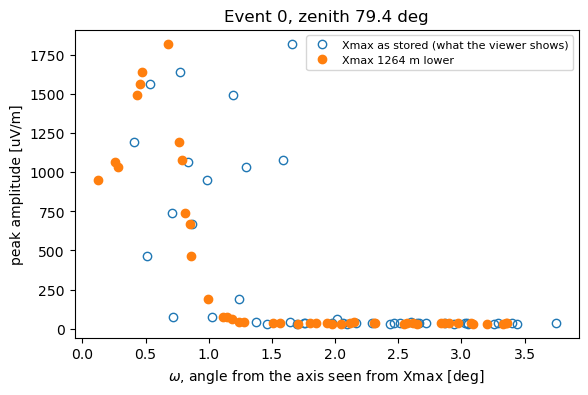

In [9]:
v, as_stored, corrected = viewers[0]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(as_stored, v.peakamplitude, "o", mfc="none", label="Xmax as stored (what the viewer shows)")
ax.plot(corrected, v.peakamplitude, "o", label="Xmax 1264 m lower")
ax.set_xlabel(r"$\omega$, angle from the axis seen from Xmax [deg]")
ax.set_ylabel("peak amplitude [uV/m]")
ax.set_title("Event 0, zenith %.1f deg" % np.degrees(v.zenith))
ax.legend(fontsize=8)
plt.show()

Measured from the corrected Xmax, amplitude falls cleanly with angle: bright
out to about 0.7°, dim beyond 1°. That is the shape notebook 11 fits. Measured
from the stored Xmax the same antennas scatter: the brightest reads 1.7°, and
antennas of equal amplitude sit a degree apart, because moving the apex by
1264 m changes each antenna's angle by a different amount. When you read the
angular plane or the Cherenkov-angle panel on these samples, read them as
illustrations of what the panels do, not as measurements. Data
produced by the current converter does not have the offset.

The ground and shower-plane panels do not use Xmax and are unaffected.

## 7. Keeping a copy: saving the page

`page.save(...)` writes the whole page to one self-contained HTML file that
opens in any browser, with no Python behind it:

In [10]:
import tempfile

out = os.path.join(tempfile.mkdtemp(), "event0.html")
with contextlib.redirect_stdout(io.StringIO()):
    page.save(out)
print("wrote %s (%.1f MB)" % (os.path.basename(out), os.path.getsize(out) / 1e6))

wrote event0.html (1.5 MB)


The file is a **snapshot**. Zooming, panning and hovering work, because the
browser does those. Clicking an antenna, **Play** and the run-directory box do
not: each of those asks Python to compute something, and a saved file has no
Python to ask. For those, serve it.

## 8. Serving it, or showing it here

From a script, `view()` serves the page, exactly as the command line does,
and keeps serving until you stop it with Ctrl-C:

```python
viewer = ev.EventViewer(SAMPLE, event=1, port=46813)
viewer.view()          # then open http://localhost:46813
```

In JupyterLab it can instead sit directly in the notebook, fully interactive,
since the kernel is the Python behind it:

```python
import panel as pn
pn.extension()
page                   # the object view(serve=False) returned
```

Neither is run here. Both need a live kernel, and GitHub, which is where most
people read these notebooks, shows neither.

## 9. What to trust

| Panel | Status |
|---|---|
| Footprint, peak times, traces | reads the data and draws it; nothing to go wrong beyond the band-pass choice |
| Background array | the 2021 *proposed* layout, not the array in the data |
| Shower plane | correct since September 2026; before that, axes rotated by 91–114° |
| Angular plane, Cherenkov angle | correct method; on the committed samples, off by up to several degrees because of their Xmax (#160) |
| Colour selector | inert: changing it does nothing until something else redraws |

The viewer's test, `tests/examples/test_eventviewer.py`, builds the whole page
against the sample run on every push, checks the tap tool reaches the hits and
not the background, the Play time bins, loading a new run, and the magnetic
field against the geomagnetic model. `examples/eventviewer/README.md` has the
viewer's history and its open items.

## Where next

- [09 — Reading events](09_reading_events.ipynb) — `grand.aoi`, which the viewer reads through
- [11 — Reconstructing a shower](11_reconstruction.ipynb) — recovering direction and Xmax from the same peak times and amplitudes
- [01 — Coordinate systems](01_coordinates.ipynb) — the x North, y West frame the panels are drawn in

<!-- provenance -->
---

*Generated by `notebooks/make_notebooks.py` on 2026-09-24 16:41 UTC, from commit `fb7e2e37` with uncommitted changes, running Python 3.12.14. Edit the generator and rebuild rather than editing this file: a notebook edited in place is overwritten by the next build, and `--check` will say so.*